In [95]:

import sys
import logging
sys.path.append('E:\wangzhilin\QuantumGalaxy')
from QGI.mysql import MYSQL

import pandas as pd
import numpy as np
from QGI.neoapi import Neo4j
from QGI.feishu import *
import os
def get_logger(name,level=None,file=None):
    logger=logging.getLogger(name)
    logger.setLevel(logging.INFO)
    
    ch=logging.StreamHandler()
    ch.setLevel(logging.INFO)
    formatter=logging.Formatter(fmt='%(asctime)s %(name)-12s %(levelname)-8s %(message)s',datefmt='%m-%d %H:%M')
    ch.setFormatter(formatter)
    
    logger.addHandler(ch)
    if file:    
        fh=logging.FileHandler("E:/wangzhilin/QuantumGalaxy/logs/%s.log"%file,'a',encoding='utf-8')
        fh.setLevel(logging.INFO)
        fh.setFormatter(formatter)
        logger.addHandler(fh)
    return logger
logger=get_logger('logger')
uri = "neo4j+ssc://08ef0a79.databases.neo4j.io"
user = "QG_Editor"
password = "editor"
neo=Neo4j(uri,user,password)


Failed to write data to connection ResolvedIPv4Address(('34.126.114.186', 7687)) (IPv4Address(('34.126.114.186', 7687)))
Failed to write data to connection IPv4Address(('08ef0a79.databases.neo4j.io', 7687)) (IPv4Address(('34.126.114.186', 7687)))


In [96]:
backbone='煤炭'
cypher='match (n) where n.backbone contains "%s" return n.name,labels(n)'%backbone
nodes=neo.read_query(cypher)
cypher='match p=(n1)-[r]->(n2) where n1.backbone contains "%s" and n2.backbone contains "%s" return startNode(r).name,endNode(r).name,type(r)'%(backbone,backbone)
edges=neo.read_query(cypher)

09-07 11:35 logger       INFO     accept cypher query match (n) where n.backbone contains "煤炭" return n.name,labels(n)
09-07 11:35 logger       INFO     accept cypher query match (n) where n.backbone contains "煤炭" return n.name,labels(n)
09-07 11:35 logger       INFO     get 20 records
09-07 11:35 logger       INFO     get 20 records
09-07 11:35 logger       INFO     accept cypher query match p=(n1)-[r]->(n2) where n1.backbone contains "煤炭" and n2.backbone contains "煤炭" return startNode(r).name,endNode(r).name,type(r)
09-07 11:35 logger       INFO     accept cypher query match p=(n1)-[r]->(n2) where n1.backbone contains "煤炭" and n2.backbone contains "煤炭" return startNode(r).name,endNode(r).name,type(r)
09-07 11:35 logger       INFO     get 20 records
09-07 11:35 logger       INFO     get 20 records


In [97]:
edges[0]

<Record startNode(r).name='合成氨' endNode(r).name='尿素' type(r)='compose'>

In [105]:
nodes[0]

<Record n.name='合成氨' labels(n)=['Product']>

In [98]:
nodes[0].values()

['合成氨', ['Product']]

In [517]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import matplotlib as mpl
import json
G=nx.DiGraph()
for node in nodes:
    G.add_node(node[0],**node[1:])
for edge in edges:
    G.add_edge(edge[0],edge[1],relationship=edge[2],)
for u,v,d in G.edges(data=True):
    if d['relationship']=='compose':
        G.edges[u,v]['velocity']=random.random()
    else:
        G.edges[u,v]['velocity']=-1

In [373]:
from math import sqrt

In [374]:
G.edges.data()

OutEdgeDataView([('合成氨', '尿素', {'relationship': 'compose', 'velocity': 0.9068480367819027}), ('甲醇', '醋酸', {'relationship': 'compose', 'velocity': 0.1341745805905994}), ('甲醇', '二甲醚', {'relationship': 'compose', 'velocity': 0.30366905523439114}), ('煤炭资源', '原煤', {'relationship': 'compose', 'velocity': 0.3482052108505834}), ('火力发电', '热力', {'relationship': 'compose', 'velocity': 0.5136872008695758}), ('动力煤', '火力发电', {'relationship': 'compose', 'velocity': 0.322996425011405}), ('动力煤', '热力', {'relationship': 'compose', 'velocity': 0.3928314678254191}), ('煤矿用设备', '原煤', {'relationship': 'compose', 'velocity': 0.11402742889107442}), ('焦炭', '生铁', {'relationship': 'compose', 'velocity': 0.8431530656763135}), ('焦炭', '合成气', {'relationship': 'compose', 'velocity': 0.40276191551800244}), ('焦炭', '鼓风炉熔炼', {'relationship': 'compose', 'velocity': 0.08641493581073467}), ('炼焦煤', '甲醇', {'relationship': 'compose', 'velocity': 0.19643207403466545}), ('炼焦煤', '合成氨', {'relationship': 'compose', 'velocity': 0.1774

C:\Users\wangzhilin\AppData\Local\Temp\2\ipykernel_10940\1769463569.py:29: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(pc)


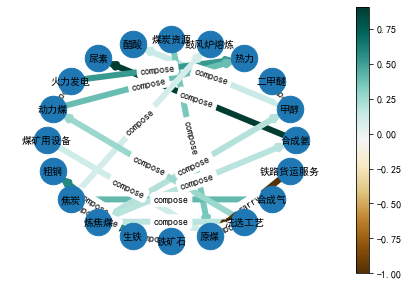

In [385]:
#pos = nx.spring_layout(G, seed=7,k=100/sqrt(len(G.nodes)))

pos=nx.circular_layout(G, dim=2)
#pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
nx.draw_networkx_nodes(G, pos, node_size=700)
edge_colors=[d['velocity'] for (u, v, d) in G.edges(data=True) ]
cmap=plt.cm.BrBG
# edges
e = [(u, v) for (u, v, d) in G.edges(data=True) ]
draw_edges=nx.draw_networkx_edges(G, pos, edgelist=e, width=6,edge_color=edge_colors,edge_cmap=cmap)


# node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(G, "relationship")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

ax = plt.gca()
ax.margins(0.1)
plt.axis("off")
plt.tight_layout()
pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
pc.set_array(edge_colors)

ax = plt.gca()
ax.set_axis_off()
plt.colorbar(pc)
plt.show()

In [278]:
[d['velocity'] for (u, v, d) in G.edges(data=True) ]

[0.004401143305187372,
 0.6676465347807793,
 0.9223832911999494,
 0.959632030739519,
 0.2737904495814151,
 0.14009865083329665,
 0.026093818751220077,
 0.7303699312374933,
 0.41397488278912764,
 0.6268510153557446,
 0.2651379298872115,
 0.9959422361732042,
 0.5437365096730532,
 0.993163372522446,
 0.9546708687536231,
 0.03128433088410432,
 0.010835054816161094,
 0.2726604594934341,
 0.19071358105639236,
 0.2572486142190711]

In [146]:
pos

{'合成氨': [0.999999988, 1.33118354e-08],
 '甲醇': array([0.95105653, 0.30901701]),
 '二甲醚': array([0.80901699, 0.58778525]),
 '热力': array([0.58778524, 0.80901701]),
 '鼓风炉熔炼': array([0.30901697, 0.95105654]),
 '煤炭资源': array([-4.21220623e-08,  1.00000000e+00]),
 '醋酸': array([-0.30901703,  0.95105648]),
 '尿素': array([-0.58778523,  0.80901701]),
 '火力发电': array([-0.80901699,  0.58778525]),
 '动力煤': array([-0.95105647,  0.30901704]),
 '煤矿用设备': array([-9.99999985e-01, -7.41109400e-08]),
 '粗钢': array([-0.95105653, -0.30901696]),
 '焦炭': array([-0.80901693, -0.58778528]),
 '炼焦煤': array([-0.58778506, -0.8090171 ]),
 '生铁': array([-0.30901712, -0.95105645]),
 '铁矿石': array([ 1.35142058e-08, -9.99999973e-01]),
 '原煤': array([ 0.30901712, -0.95105645]),
 '洗选工艺': array([ 0.58778506, -0.8090171 ]),
 '合成气': array([ 0.80901693, -0.58778528]),
 '铁路货运服务': array([ 0.95105653, -0.30901693])}

In [26]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码问题

In [240]:
plt.savefig('E:\wangzhilin\QuantumGalaxy\\backbone\\figs\\text.png')

<Figure size 432x288 with 0 Axes>

In [520]:
class Backbone_handler():
    def __init__(self,G:nx.Graph):
        self.G=G

    def nodes_group_by_label(self):
        G=self.G
        self.product={}
        self.company={}
        self.technique={}
        self.nodes={'product':self.product,'company':self.company,'technique':self.technique}
        for node,attr in G.nodes(True):
            labels=attr['labels(n)']
            if 'Product' in labels:
                self.product[node]=attr
            elif 'Company' in labels:
                self.company[node]=attr
            elif 'Technique' in labels:
                self.technique[node]=attr
        
    def edges_group_by_rela(self):
        G=self.G
        self.carry=[]
        self.compose=[]
        self.edges={'compose':self.compose,'carry':self.carry}
        for s,e,attr in G.edges(data=True):
            rela=attr['relationship']
            if 'compose' in rela:
                self.compose.append((s,e,attr))
            if 'carry' in rela:
                self.carry.append((s,e,attr))

    def draw_graph(self):
        cmap=plt.cm.winter_r
        self.nodes_group_by_label()
        self.edges_group_by_rela()
        #pos=nx.spring_layout(G,k=1/sqrt(len(self.G.nodes)),weight=None,scale=1,seed=20)
        pos=nx.spring_layout(self.G,k=1e4/self.G.number_of_nodes(),weight='velocity',scale=1,seed=1,iterations=10000,threshold=1e-15)
        #pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
        #pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
        fig, ax = plt.subplots(dpi=200)
        for label,nodes in self.nodes.items():
            if label=='product':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"o",}
            #print(draw_args)
            elif label=='technique':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"v",}
            nx.draw_networkx_nodes(G, pos=pos,ax=ax, **draw_args)

        # edges
        
        edge_colors=[]
        for rela,edges in self.edges.items():
                
            e = [(u, v) for (u, v, d) in edges ]
            colors=[d['velocity'] for (u, v, d) in edges ]
            draw_args={'width':6,'edge_color':"k",'style':"solid",'alpha':None,'arrowstyle':"-|>",'arrowsize':10,'label':None,'edge_color':colors,'edge_cmap':cmap}
            nx.draw_networkx_edges(G, pos, edgelist=e, ax=ax,**draw_args)
            edge_colors+=colors
        #edge_colors=[d['velocity'] for (u, v, d) in G.edges(data=True) ]
        
        # node labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif",ax=ax)
        # edge weight labels
        edge_labels = nx.get_edge_attributes(G, "velocity")
        edge_labels={k:round(v,2) for k,v in edge_labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels,ax=ax)

        ax = plt.gca()
        ax.margins(0.1)
        plt.axis("off")
        plt.tight_layout()
        pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
        pc.set_array(edge_colors)

        ax = plt.gca()
        #ax.set_axis_off()
        plt.colorbar(pc,ax=ax)
        plt.show()
        return(draw_edges)
    def export_json(self):
        pass

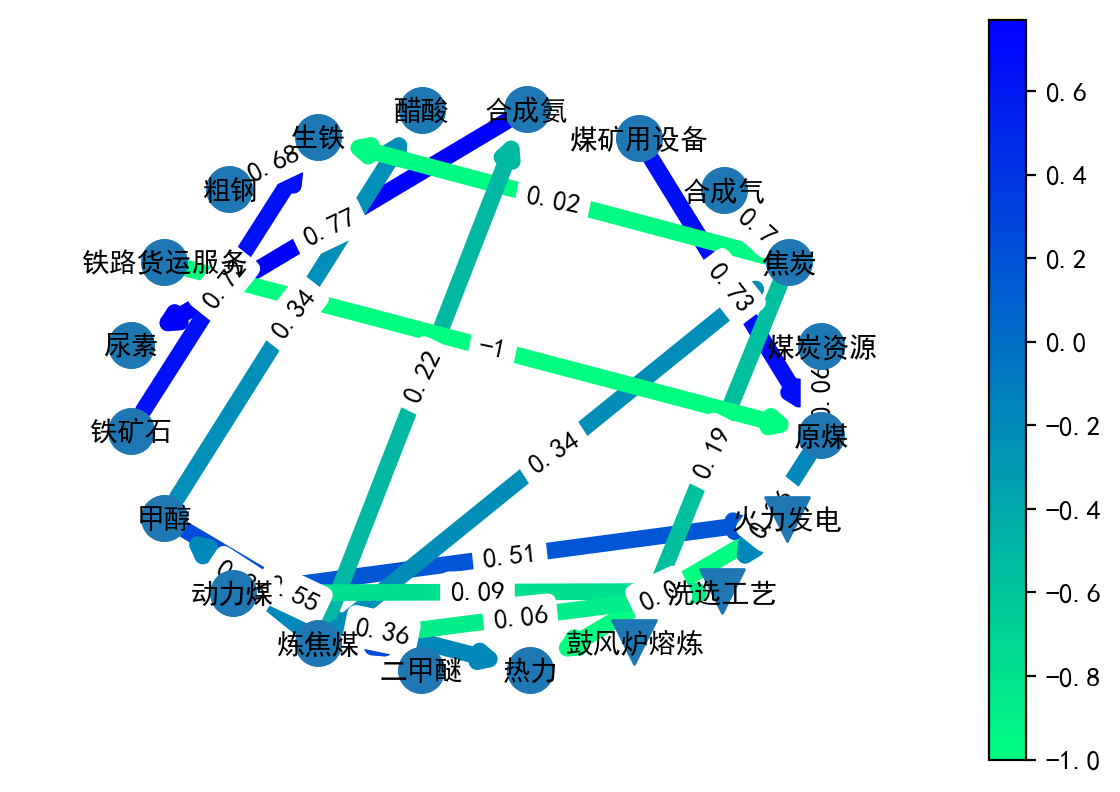

In [521]:
a=Backbone_handler(G)
e=a.draw_graph()

In [493]:
a.edges

{'compose': [('合成氨',
   '尿素',
   {'relationship': 'compose', 'velocity': 0.5614280731796653}),
  ('甲醇', '醋酸', {'relationship': 'compose', 'velocity': 0.6580405141609632}),
  ('甲醇', '二甲醚', {'relationship': 'compose', 'velocity': 0.4384770075890456}),
  ('煤炭资源', '原煤', {'relationship': 'compose', 'velocity': 0.4172524630318465}),
  ('火力发电', '热力', {'relationship': 'compose', 'velocity': 0.806323579313485}),
  ('动力煤',
   '火力发电',
   {'relationship': 'compose', 'velocity': 0.40591087282990246}),
  ('动力煤', '热力', {'relationship': 'compose', 'velocity': 0.6157958796334719}),
  ('煤矿用设备',
   '原煤',
   {'relationship': 'compose', 'velocity': 0.032695953897533214}),
  ('焦炭', '生铁', {'relationship': 'compose', 'velocity': 0.8564478351616353}),
  ('焦炭', '合成气', {'relationship': 'compose', 'velocity': 0.18018319801793237}),
  ('焦炭',
   '鼓风炉熔炼',
   {'relationship': 'compose', 'velocity': 0.39959658218034877}),
  ('炼焦煤', '甲醇', {'relationship': 'compose', 'velocity': 0.2595777949264756}),
  ('炼焦煤', '合成氨', {'

In [309]:
len(e)

20

In [153]:
for k,v in a.nodes.items():
    print(v)

{'合成氨': {'labels(n)': ['Product']}, '甲醇': {'labels(n)': ['Product']}, '二甲醚': {'labels(n)': ['Product']}, '热力': {'labels(n)': ['Product']}, '煤炭资源': {'labels(n)': ['Product']}, '醋酸': {'labels(n)': ['Product']}, '尿素': {'labels(n)': ['Product']}, '动力煤': {'labels(n)': ['Product']}, '煤矿用设备': {'labels(n)': ['Product']}, '粗钢': {'labels(n)': ['Product']}, '焦炭': {'labels(n)': ['Product']}, '炼焦煤': {'labels(n)': ['Product']}, '生铁': {'labels(n)': ['Product']}, '铁矿石': {'labels(n)': ['Product']}, '原煤': {'labels(n)': ['Product']}, '合成气': {'labels(n)': ['Product']}, '铁路货运服务': {'labels(n)': ['Product']}}
{}
{}


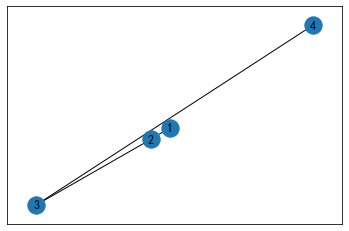

In [516]:
G=nx.Graph()
G.add_edge(1,2,velocity=100)
G.add_edge(2,3,velocity=1)
G.add_edge(3,4,velocity=-50)
nx.draw_networkx(G,pos=nx.spring_layout(G,weight='velocity'))